# **Regressão Linear Aplicada**

Introdução Teórica (resumida)

**O que é Regressão Linear**: Técnica estatística para modelar a relação entre uma variável dependente (Y) e uma ou mais variáveis independentes (X).

Objetivo:
Predizer ou explicar o comportamento de Y a partir de X.

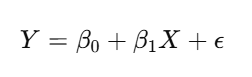

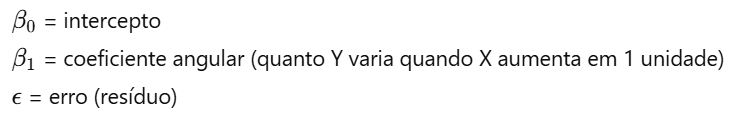

**Linearidade**: A relação entre X e Y deve ser aproximadamente linear.

**Independência dos erros**: Os resíduos não devem estar correlacionados.

**Homoscedasticidade**: Variância dos erros constante ao longo de todos os valores de X.

**Normalidade dos erros**: Resíduos devem ter distribuição aproximadamente normal (importante para inferência).

**Ausência de multicolinearidade** (no caso de múltipla): Variáveis independentes não devem ser altamente correlacionadas entre si.

**Boa qualidade do ajuste**: Avaliada por métricas como
𝑅², RMSE e análise dos resíduos.

In [2]:
import pandas as pd
import numpy as np

# Simulação de dados financeiros (12 meses)
np.random.seed(42)
X = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65])  # Investimento em Marketing (mil R$)
Y = 5 + 2.5*X + np.random.normal(0, 10, size=len(X))  # Lucro (mil R$) com ruído

# Criando DataFrame
df = pd.DataFrame({"Investimento_Marketing": X, "Lucro": Y})
df


,Investimento_Marketing,Lucro
0,10,34.967142
1,15,41.117357
2,20,61.476885
3,25,82.730299
4,30,77.658466
5,35,90.158630
6,40,120.792128
7,45,125.174347
8,50,125.305256
9,55,147.925600


Intercepto (β0): 13.045279480096298
Coeficiente (β1): 2.364380628766429
R²: 0.9735235538069241
RMSE: 6.730098283971085


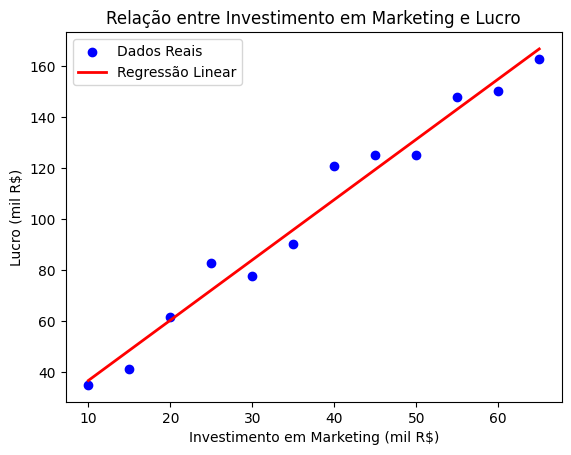

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Reshape do X
X_reshaped = X.reshape(-1, 1)

# Modelo
modelo = LinearRegression()
modelo.fit(X_reshaped, Y)

# Predição
Y_pred = modelo.predict(X_reshaped)

# Resultados
print("Intercepto (β0):", modelo.intercept_)
print("Coeficiente (β1):", modelo.coef_[0])
print("R²:", r2_score(Y, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y, Y_pred)))

# Visualização
plt.scatter(X, Y, color="blue", label="Dados Reais")
plt.plot(X, Y_pred, color="red", linewidth=2, label="Regressão Linear")
plt.xlabel("Investimento em Marketing (mil R$)")
plt.ylabel("Lucro (mil R$)")
plt.title("Relação entre Investimento em Marketing e Lucro")
plt.legend()
plt.show()

**1) Linearidade**

O que é: a relação média entre X e Y deve ser (aproximadamente) linear.

Como verificar (rápido):

Gráfico Y vs. X (ou Y vs. cada X).

Gráfico resíduos vs. valores preditos (espera-se “nuvem” sem padrão).

**2) Resíduo**

Em análise de forecasting (previsão) e estatística, um resíduo é a diferença entre o valor real observado (y) e o valor previsto (y') por um modelo. Ele representa a parte dos dados que o modelo não conseguiu explicar, sendo frequentemente interpretado como o erro de previsão.

A fórmula básica é: **resíduo = valor real - valor previsto**

**Principais Aspectos dos Resíduos**:
**Significado**: Se o resíduo for positivo, o modelo subestimou o valor (previsão abaixo do real). Se for negativo, o modelo superestimou (previsão acima do real).


**Finalidade da Análise**: A análise de resíduos é essencial para verificar a adequação do modelo. Um bom modelo deve gerar resíduos que sejam, idealmente, "ruído branco", ou seja, aleatórios, sem padrões discerníveis.

**Padrões nos Resíduos**: Se os resíduos apresentarem um padrão (como uma curva ou tendência), isso indica que o modelo não capturou todas as informações dos dados, como sazonalidade ou tendências lineares, e precisa ser ajustado.

**Diagnóstico de Qualidade**: Resíduos com variância constante (homoscedasticidade) e distribuição normal são desejáveis para garantir a confiabilidade das previsões.

**3) Independência dos erros (autocorrelação)**

O que é: resíduos não devem estar correlacionados entre si.
Atenção em séries temporais (ex.: meses): marketing e lucro de um mês tendem a “carregar” efeito do mês anterior.

**Como verifica**r:

Resíduos ao longo do tempo (resíduo vs. mês): procurar padrões/ondas.

Durbin–Watson (DW): próximo de 2 é bom; muito abaixo de 2 sugere autocorrelação positiva.

**Sinais de problema**:

Padrões cíclicos nos resíduos ao longo do tempo.

DW ≪ 2 (autocorrelação positiva) ou ≫ 2 (negativa).

**4) Homoscedasticidade (variância constante dos erros)**

O que é: a dispersão dos resíduos deve ser aproximadamente constante ao longo dos níveis de X (ou dos valores preditos).

Como verificar:

Gráfico resíduos vs. predito: procurar “funil” (dispersão crescendo/diminuindo).

Testes como Breusch–Pagan / White.

Sinais de problema:

“Funil” ou “megafone”: variância pequena para predições baixas e grande para altas (ou o inverso).

Rejeição em Breusch–Pagan/White.

O que fazer:
Erros-padrão robustos à heteroscedasticidade (HC3) quando o foco é inferência.

**O que uma boa análise de resíduos busca?**

- Média zero: O modelo não deve ser consistentemente alto ou baixo.

- Variância constante (Homoscedasticidade): O erro não deve aumentar ou diminuir ao longo do tempo ou conforme o valor da previsão muda.

- Independência: Resíduos não devem ser autocorrelacionados (o valor atual não deve depender do valor passado).

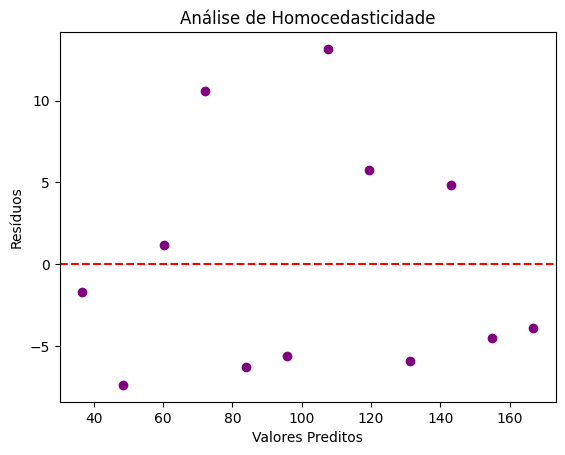

In [4]:
import seaborn as sns
import scipy.stats as stats

# Resíduos
residuos = Y - Y_pred

# 1. Linearidade (já vista no gráfico de dispersão)
# 2. Homocedasticidade
plt.scatter(Y_pred, residuos, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.title("Análise de Homocedasticidade")
plt.show()

In [5]:
import statsmodels.stats.api as sms

# 2. Independência dos erros (autocorrelação)
# Durbin-Watson test
dw_test = sms.durbin_watson(residuos)
print("Durbin-Watson:", dw_test)

if dw_test < 1.5 or dw_test > 2.5:
    print("⚠️ Possível indício de autocorrelação nos resíduos")
else:
    print("✅ Sem forte indício de autocorrelação nos resíduos")

Durbin-Watson: 2.2645021722782186
✅ Sem forte indício de autocorrelação nos resíduos


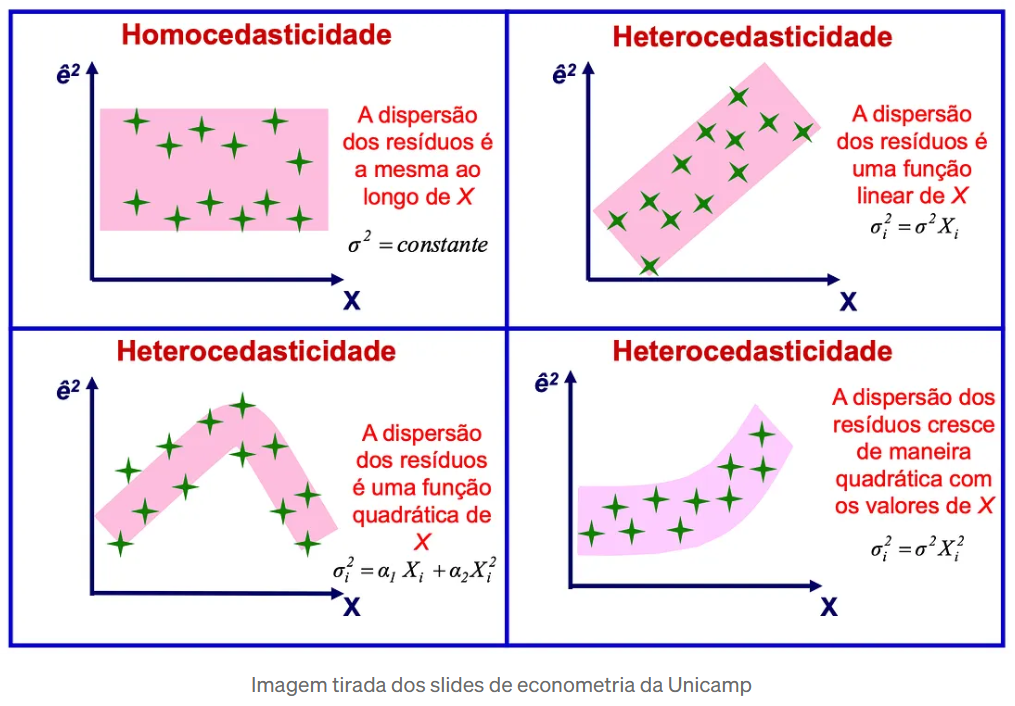

In [6]:
import statsmodels.api as sm

# 3. Homocedasticidade (variância constante dos erros)
# Adicionando constante ao X para o teste
X_ = sm.add_constant(X)

# Breusch-Pagan test
bp_test = sm.stats.diagnostic.het_breuschpagan(residuos, X_)
print(f"Breusch-Pagan test: p-value = {bp_test[1]:.4f}")

if bp_test[1] < 0.05:
    print("⚠️ Possível indício de heterocedasticidade (rejeita H0)")
else:
    print("✅ Sem forte indício de heterocedasticidade (não rejeita H0)")

# White test
white_test = sm.stats.diagnostic.het_white(residuos, X_)
print(f"White test: p-value = {white_test[1]:.4f}")

if white_test[1] < 0.05:
    print("⚠️ Possível indício de heterocedasticidade (rejeita H0)")
else:
    print("✅ Sem forte indício de heterocedasticidade (não rejeita H0)")

Breusch-Pagan test: p-value = 0.8062
✅ Sem forte indício de heterocedasticidade (não rejeita H0)
White test: p-value = 0.2258
✅ Sem forte indício de heterocedasticidade (não rejeita H0)


**4) Normalidade dos erros (para inferência)**

O que é: resíduos ~ Normais (especialmente importante para p-valores e ICs com amostra pequena).

Como verificar:

Histograma e Q–Q plot dos resíduos.

Testes como Shapiro–Wilk (cuidado: com n pequeno, pouco poder; com n grande, tudo rejeita).

Sinais de problema:

Caudas mais pesadas/finas no Q–Q plot; assimetria forte.

O que fazer:

Com n moderado/grande, a normalidade é menos crítica (teorema central), mas sempre cheque influência.

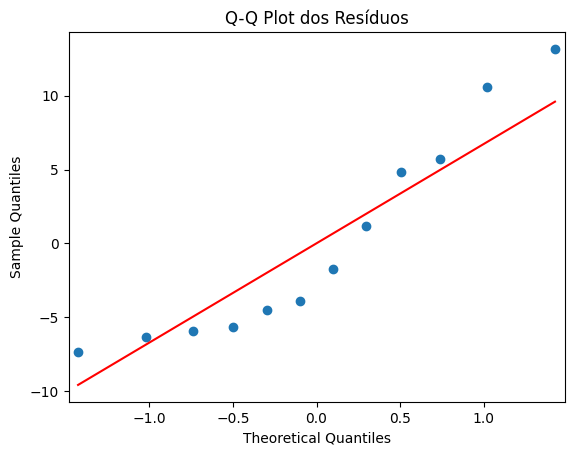

Shapiro-Wilk p-valor: 0.08856000749797185
✅ Resíduos seguem distribuição normal (não rejeita H0)


In [7]:
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# 4. Normalidade dos resíduos

# Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q Plot dos Resíduos")
plt.show()

# Teste de Shapiro-Wilk
stat, p = stats.shapiro(residuos)
print("Shapiro-Wilk p-valor:", p)
if p > 0.05:
    print("✅ Resíduos seguem distribuição normal (não rejeita H0)")
else:
    print("⚠️ Resíduos podem não ser normais")

**5) Ausência de multicolinearidade (somente na regressão múltipla)**

O que é: preditoras não devem ser combinações quase perfeitas entre si.

Como verificar:

VIF (Variance Inflation Factor): regra prática VIF > 5 (às vezes 10) sinaliza alerta.

Matriz de correlação entre X’s.

Sinais de problema:

Coeficientes instáveis, sinais “estranhos”, ICs muito largos.

O que fazer:

Remover/combinar variáveis redundantes;

Regularização (Ridge/Lasso);

PCA para reduzir dimensionalidade (quando faz sentido interpretativo).

## Snippets úteis - Atalhos

                            OLS Regression Results                            
Dep. Variable:                  Lucro   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     367.7
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.24e-09
Time:                        12:03:58   Log-Likelihood:                -39.906
No. Observations:                  12   AIC:                             83.81
Df Residuals:                      10   BIC:                             84.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     13

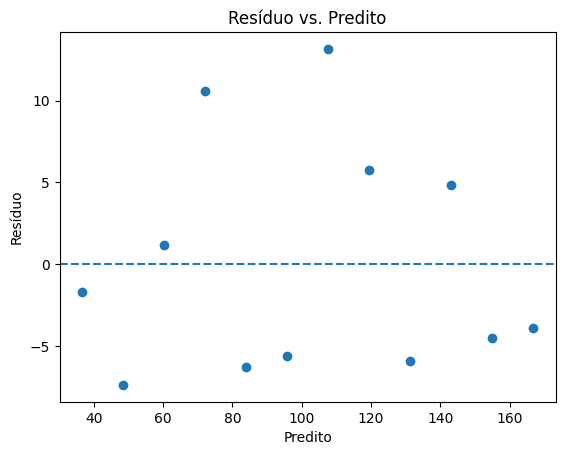

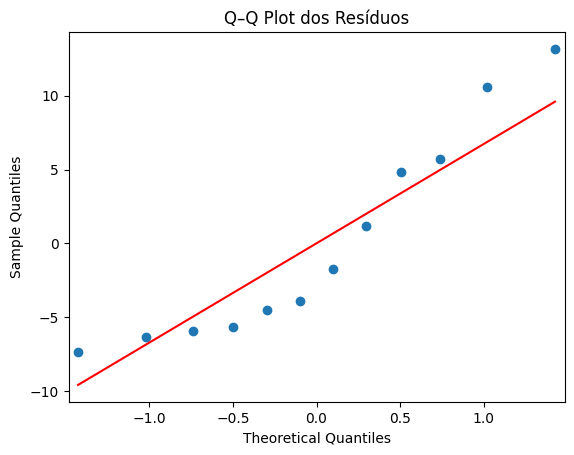

Durbin-Watson: 2.26450217227822
{'LM stat': np.float64(0.060214583395759025), 'LM p-val': np.float64(0.8061571036484794), 'F stat': np.float64(0.050431880720419126), 'F p-val': np.float64(0.8268356177289633)}
Máx Cook’s D: 0.18830545623460818


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

# 1) Ajuste OLS
X_ = sm.add_constant(df[['Investimento_Marketing']])  # para múltipla, inclua mais colunas
y_ = df['Lucro']
ols = sm.OLS(y_, X_).fit()
print(ols.summary())

# 2) Resíduos e preditos
res = ols.resid
fitted = ols.fittedvalues

# 3) Linearidade e homoscedasticidade (visual)
plt.scatter(fitted, res); plt.axhline(0, linestyle='--'); plt.xlabel('Predito'); plt.ylabel('Resíduo'); plt.title('Resíduo vs. Predito'); plt.show()

# 4) Normalidade (Q–Q)
sm.qqplot(res, line='s'); plt.title('Q–Q Plot dos Resíduos'); plt.show()

# Durbin–Watson (independência)
print("Durbin-Watson:", durbin_watson(res))

# Breusch–Pagan (homoscedasticidade)
bp = het_breuschpagan(res, X_)
labels = ['LM stat','LM p-val','F stat','F p-val']
print(dict(zip(labels, bp)))

# Influência de Outliers
infl = OLSInfluence(ols)
cook = infl.cooks_distance[0]
print("Máx Cook’s D:", np.max(cook))
